# Train DAF 

In [1]:
#!/usr/bin/env python
import sys
import torch
import random
import time
from models import *
from utils import *
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from torch.utils.data.sampler import SubsetRandomSampler
import os
import logging
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
import itertools


class Generator(nn.Module):
    def __init__(self, input_nc, output_nc, init_depth, s_depth, bc=True, n_residual_blocks=9, domains=2, log=True):
        super(Generator, self).__init__()

        self.z_size = 17 if bc else 7
        #### encode
        ec = [   nn.ReflectionPad2d(3),
                    nn.Conv2d(input_nc, init_depth, 7),
                    nn.InstanceNorm2d(init_depth),
                    nn.ReLU(inplace=True) ]

        # Downsampling
        ec += [  nn.Conv2d(init_depth, init_depth*2, 3, stride=2, padding=1),
                 nn.InstanceNorm2d(init_depth*2),
                 nn.ReLU(inplace=True) ]
        
        ec += [  nn.Conv2d(init_depth*2, init_depth*4-s_depth, 3, stride=2, padding=1),
                 nn.InstanceNorm2d(init_depth*4-s_depth),
                 nn.ReLU(inplace=True) ]
        in_features = init_depth*4-s_depth
        
        # Residual blocks
        for _ in range(n_residual_blocks):
            ec += [ResidualBlock(in_features)]
        
        #### encode
        self.ec = nn.Sequential(*ec)
        # Embed layer
        self.s_depth = s_depth
        self.embed = nn.Embedding(domains, self.z_size*self.z_size*s_depth)
        self.z1 = nn.Conv2d(in_features, int((in_features + s_depth)/2), 5, stride=4)
        self.tconv1 = nn.ConvTranspose2d(int((in_features + s_depth)/2), int((in_features + s_depth)/2), kernel_size=5, stride=4, padding=1, output_padding=2)
        self.tconv2 = nn.ConvTranspose2d(int((in_features + s_depth)/2), in_features, kernel_size=1, stride=1)
        
        #### decode
        in_features = init_depth*4
        dc = []            
        # Upsampling
        out_features = in_features//2
        for _ in range(2):
            dc += [  nn.ConvTranspose2d(in_features, out_features, 3, stride=2, padding=1, output_padding=1),
                     nn.InstanceNorm2d(out_features),
                     nn.ReLU(inplace=True) ]
            in_features = out_features
            out_features = in_features//2
        
        # # Output layer
        # if log:
        #     dc += [  nn.ReflectionPad2d(3),
        #              nn.Conv2d(init_depth, output_nc, 7),
        #              nn.ReLU()]
        # else:
        #     dc += [  nn.ReflectionPad2d(3),
        #              nn.Conv2d(init_depth, output_nc, 7),
        #              nn.Tanh() ]
        #### decode
        self.dc = nn.Sequential(*dc)
        
        # Dual-heads: mask and value
        self.mask_head = nn.Conv2d(in_features, 1, kernel_size=1)
        self.val_head  = nn.Conv2d(in_features, 1, kernel_size=1)
        
        self.log = log
        
    def forward(self, x, s):
        x = self.ec(x)
        x = self.z1(x)
        z = x.view(x.shape[0], -1)
        x = self.tconv2(self.tconv1(x))
        ##
        s_x = self.embed(s).view(x.shape[0], self.s_depth, self.z_size, self.z_size)
        xs = torch.cat((x,s_x),dim=1)
        
        # Decode backbone
        pre = self.dc(xs)
        # Heads
        mask_logit = self.mask_head(pre)
        val_log    = self.val_head(pre)
        # Probability mask
        P = torch.sigmoid(mask_logit)
        # Value to rate
        rate = torch.exp(val_log) if self.log else F.softplus(val_log)
        # Symmetrize mask and rate to preserve zeros
        P_sym   = torch.max(P, P.transpose(-1, -2))
        rate_sym= 0.5 * (rate + rate.transpose(-1, -2))
        # Combined adjacency
        Ahat = P_sym * rate_sym
        # Enforce symmetry and zero diag
        Ahat = 0.5 * (Ahat + Ahat.transpose(-1, -2))
        eye = torch.eye(Ahat.size(-1), device=Ahat.device)
        Ahat = Ahat * (1 - eye)
        return Ahat, z
    

# Setup logging
logging.basicConfig(filename='./logs/daf-sleep-abcd-modified.log', level=logging.INFO, 
                    format='%(asctime)s - %(levelname)s - %(message)s')

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

def set_seed(seed_value=973028):
    """Set seed for reproducibility."""
    random.seed(seed_value)  # Python random module
    np.random.seed(seed_value)  # Numpy module
    torch.manual_seed(seed_value)  # PyTorch
    os.environ['PYTHONHASHSEED'] = str(seed_value)  # Python hash seed
    
    # CUDA reproducibility
    torch.cuda.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)  # if use multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

# Unsupervised DAF

## Load brain connectome data with sleep information
print("Loading ABCD data with sleep information...")
dat_abcd = loadmat('../abcd/new_abcd_cog_with_sleep_filtered.mat')
tensor_abcd = dat_abcd['count_network']
sleep_domain_numeric = dat_abcd['sleep_domain_numeric']

# whether to apply log transformation to the adjacency matrices
log = True

set_seed(1972014)

# Extract matrices for short sleep (0) and long sleep (1)
net_short_sleep = []
net_long_sleep = []

for i in range(tensor_abcd.shape[2]):
    ith = np.float32(tensor_abcd[:,:,i])
    if log:
        ith = np.log(ith+1)
    ith = ith.reshape(68*68)
    
    # Check sleep domain (0=short, 1=long)
    sleep_value = sleep_domain_numeric[i][0]
    if sleep_value == 0:  # Short sleep
        net_short_sleep.append(ith)
    elif sleep_value == 1:  # Long sleep
        net_long_sleep.append(ith)

n_short = len(net_short_sleep)
n_long = len(net_long_sleep)

print(f'Short sleep: {n_short} subjects')
print(f'Long sleep: {n_long} subjects')

# Combine the data
net_all = net_short_sleep + net_long_sleep

## Preprocess the data
if log:
    # If log transformation was applied, stack the tensors
    net_all = torch.stack([torch.Tensor(i) for i in net_all]).view(-1, 1, 68, 68)
else:
    # If no log transformation, scale data to range [0,1] (default in cycle gan)
    offset = np.max(net_all)/2
    net_all = torch.stack([torch.Tensor((i-offset)/offset) for i in net_all]).view(-1, 1, 68, 68)

# Domain labels: Short Sleep (0), Long Sleep (1)
labels = torch.cat((torch.tensor([0]).expand(n_short, 1), torch.tensor([1]).expand(n_long, 1)))

## Data loader
set_seed(1972034)
nepoch = 300
dataset = utils.TensorDataset(net_all, labels)

# Split train and validation
train_id, test_id = train_test_split(list(range(n_short + n_long)), train_size=0.9, random_state=42)
train_dataset = utils.Subset(dataset, train_id)
test_dataset = utils.Subset(dataset, test_id)
train_loader = utils.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = utils.DataLoader(test_dataset, batch_size=len(test_id), shuffle=False)

## DAF model configuration
# Networks
set_seed(1972014)
netG_A2B = Generator(input_nc=1, output_nc=1, init_depth=48, s_depth=10, n_residual_blocks=5).to(device)
netG_B2A = Generator(input_nc=1, output_nc=1, init_depth=48, s_depth=10, n_residual_blocks=5).to(device)
netD_A = Discriminator(input_nc=1, init_depth=48).to(device)
netD_B = Discriminator(input_nc=1, init_depth=48).to(device)

# Losses
criterion_GAN = torch.nn.MSELoss()
criterion_cycle = torch.nn.L1Loss()

# Optimizers & LR schedulers
optimizer_G = torch.optim.Adam(itertools.chain(netG_A2B.parameters(), netG_B2A.parameters()),
                               lr=0.0002, betas=(0.5, 0.999))
optimizer_D_A = torch.optim.Adam(netD_A.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D_B = torch.optim.Adam(netD_B.parameters(), lr=0.0002, betas=(0.5, 0.999))

lr_scheduler_G = torch.optim.lr_scheduler.LambdaLR(optimizer_G, lr_lambda=LambdaLR(nepoch, 0, nepoch/2).step)
lr_scheduler_D_A = torch.optim.lr_scheduler.LambdaLR(optimizer_D_A, lr_lambda=LambdaLR(nepoch, 0, nepoch/2).step)
lr_scheduler_D_B = torch.optim.lr_scheduler.LambdaLR(optimizer_D_B, lr_lambda=LambdaLR(nepoch, 0, nepoch/2).step)

## Train
train_G_loss = []
test_G_loss = []
train_DA_loss = []
test_DA_loss = []
train_DB_loss = []
test_DB_loss = []

# New metrics for tracking discriminator accuracy
train_DA_acc = []
test_DA_acc = []
train_DB_acc = []
test_DB_acc = []

# Frequency to monitor test loss
evaluate_every = 1

# Function to calculate discriminator accuracy
def calculate_accuracy(pred, target, threshold=0.5):
    pred_binary = (pred > threshold).float()
    correct = (pred_binary == target).float().sum()
    accuracy = correct / target.size(0)
    return accuracy.item()

# Modified evaluate function to track discriminator accuracy
def evaluate_with_accuracy(netG_A2B, netG_B2A, netD_A, netD_B, loader, epoch, device, save=False, plot=False, root=None):
    criterion_GAN = torch.nn.MSELoss()
    criterion_cycle = torch.nn.L1Loss()
    netG_A2B.eval()
    netG_B2A.eval()
    netD_A.eval()
    netD_B.eval()

    G_losses = []
    DA_losses = []
    DB_losses = []
    DA_accs = []
    DB_accs = []
    gan = []
    cyc = []
    dep = []

    with torch.no_grad():
        for i, (A, s) in enumerate(loader):
            real_A = A.to(device)
            real_B = A.to(device)
            s = s.to(device)
            bs = real_A.shape[0]

            # Inputs & targets memory allocation
            Tensor = torch.FloatTensor
            target_real = Variable(Tensor(bs, 1).fill_(1.0), requires_grad=False).to(device)
            target_fake = Variable(Tensor(bs, 1).fill_(0.0), requires_grad=False).to(device)

            # Generator evaluation
            fake_B, _ = netG_A2B(real_A, s)
            pred_fake_B = netD_B(fake_B)
            loss_GAN_A2B = criterion_GAN(pred_fake_B, target_real)

            fake_A, _ = netG_B2A(real_B, s)
            pred_fake_A = netD_A(fake_A)
            loss_GAN_B2A = criterion_GAN(pred_fake_A, target_real)

            # Cycle loss
            recovered_A, _ = netG_B2A(fake_B, s)
            loss_cycle_ABA = criterion_cycle(recovered_A, real_A) * 10.0

            recovered_B, _ = netG_A2B(fake_A, s)
            loss_cycle_BAB = criterion_cycle(recovered_B, real_B) * 10.0

            # Dependence loss
            xt = fake_B.view(bs, -1)
            s_view = s.view(bs, 1)
            DLR = dependence(xt, s_view, sig=20, device=device)

            # Total generator loss
            loss_G = loss_GAN_A2B + loss_GAN_B2A + loss_cycle_ABA + loss_cycle_BAB + DLR

            # Discriminator A evaluation
            pred_real_A = netD_A(real_A)
            loss_D_real_A = criterion_GAN(pred_real_A, target_real)
            pred_fake_A = netD_A(fake_A.detach())
            loss_D_fake_A = criterion_GAN(pred_fake_A, target_fake)
            loss_D_A = (loss_D_real_A + loss_D_fake_A) * 0.5

            # Discriminator B evaluation
            pred_real_B = netD_B(real_B)
            loss_D_real_B = criterion_GAN(pred_real_B, target_real)
            pred_fake_B = netD_B(fake_B.detach())
            loss_D_fake_B = criterion_GAN(pred_fake_B, target_fake)
            loss_D_B = (loss_D_real_B + loss_D_fake_B) * 0.5

            # Calculate discriminator accuracies
            acc_real_A = calculate_accuracy(pred_real_A, target_real)
            acc_fake_A = calculate_accuracy(pred_fake_A, target_fake)
            acc_D_A = (acc_real_A + acc_fake_A) / 2.0

            acc_real_B = calculate_accuracy(pred_real_B, target_real)
            acc_fake_B = calculate_accuracy(pred_fake_B, target_fake)
            acc_D_B = (acc_real_B + acc_fake_B) / 2.0

            # Collect metrics
            G_losses.append(loss_G.data.item())
            DA_losses.append(loss_D_A.data.item())
            DB_losses.append(loss_D_B.data.item())
            DA_accs.append(acc_D_A)
            DB_accs.append(acc_D_B)
            gan.append(loss_GAN_A2B.data.item() + loss_GAN_B2A.data.item())
            cyc.append(loss_cycle_ABA.data.item() + loss_cycle_BAB.data.item())
            dep.append(DLR.data.item())

        # Calculate mean values
        G_loss_epoch = np.mean(G_losses)
        DA_loss_epoch = np.mean(DA_losses)
        DB_loss_epoch = np.mean(DB_losses)
        DA_acc_epoch = np.mean(DA_accs)
        DB_acc_epoch = np.mean(DB_accs)
        gan_epoch = np.mean(gan)
        cyc_epoch = np.mean(cyc)
        dep_epoch = np.mean(dep)

    if save:
        if not os.path.exists(root):
            # Create the directory
            os.makedirs(root)
            print(f"Directory '{root}' was created.")
            
        torch.save(netG_A2B.state_dict(), root+'G_A2B_e'+str(epoch)+'_G'+str(np.round(G_loss_epoch,3))\
                   +'_gan'+str(np.round(gan_epoch,3)) + '_cyc'+str(np.round(cyc_epoch)) + '_dep'+ str(np.round(dep_epoch*100,3)) + '.pth')
        torch.save(netG_B2A.state_dict(), root+'G_B2A_e'+str(epoch)+'_G'+str(np.round(G_loss_epoch,3))\
                   +'_gan'+str(np.round(gan_epoch,3)) + '_cyc'+str(np.round(cyc_epoch)) + '_dep'+ str(np.round(dep_epoch*100,3)) + '.pth')
        torch.save(netD_A.state_dict(), root+'D_A_e'+str(epoch)+'_'+str(np.round(DA_loss_epoch,3))+'.pth')
        torch.save(netD_B.state_dict(), root+'D_B_e'+str(epoch)+'_'+str(np.round(DB_loss_epoch,3))+'.pth')
        
    if plot:
        with torch.no_grad():
            for i, (x, s) in enumerate(loader):
                x, s = x.to(device), s.to(device)
                xt, _ = netG_A2B(x, s)
                recov, _ = netG_B2A(xt, s)

        x = x.detach().cpu()
        xt = xt.detach().cpu()
        recov = recov.detach().cpu()
        s = s.detach().cpu() 
        output_root = root+'figs/'
        if not os.path.exists(output_root):
            # Create the directory
            os.makedirs(output_root)
            print(f"Directory '{output_root}' was created.")
        img_grid_eval(epoch, x, xt, recov, s, file = output_root+'e'+str(epoch)+'.png', nrow=3, ncol=6)
    
    return G_loss_epoch, DA_loss_epoch, DB_loss_epoch, DA_acc_epoch, DB_acc_epoch, gan_epoch, cyc_epoch, dep_epoch

# Training loop
for epoch in range(0, nepoch):
    G_losses = []
    DA_losses = []
    DB_losses = []
    DA_accs = []
    DB_accs = []
    gan = []
    cyc = []
    dep = []

    tic = time.perf_counter()
    netG_A2B.train()
    netG_B2A.train()
    netD_A.train()
    netD_B.train()
    
    for i, (A, s) in enumerate(train_loader):
        # Set model input
        real_A = A.to(device)
        real_B = A.to(device)
        s = s.to(device)
        bs = real_A.shape[0]
        
        # Inputs & targets memory allocation
        Tensor = torch.FloatTensor
        target_real = Variable(Tensor(bs,1).fill_(1.0), requires_grad=False).to(device)
        target_fake = Variable(Tensor(bs,1).fill_(0.0), requires_grad=False).to(device)
        
        ###### Generators A2B and B2A ######
        optimizer_G.zero_grad()
        
        # GAN loss 
        fake_B, _ = netG_A2B(real_A, s)
        pred_fake_B = netD_B(fake_B)
        loss_GAN_A2B = criterion_GAN(pred_fake_B, target_real)
        
        fake_A, _ = netG_B2A(real_B, s)
        pred_fake_A = netD_A(fake_A)
        loss_GAN_B2A = criterion_GAN(pred_fake_A, target_real)
        
        # Cycle loss
        recovered_A, _ = netG_B2A(fake_B, s)
        loss_cycle_ABA = criterion_cycle(recovered_A, real_A) * 10.0

        recovered_B, _ = netG_A2B(fake_A, s)
        loss_cycle_BAB = criterion_cycle(recovered_B, real_B) * 10.0
        
        # Dependence loss - makes sure the transformed features are independent of domain 
        xt = fake_B.view(bs, -1)
        s_view = s.view(bs, 1)
        DLR = dependence(xt, s_view, sig=20, device=device) 

        # Total generator loss
        loss_G = loss_GAN_A2B + loss_GAN_B2A + loss_cycle_ABA + loss_cycle_BAB + DLR
        loss_G.backward()
        optimizer_G.step()
        
        ###### Discriminator A ######
        optimizer_D_A.zero_grad()

        # Real loss
        pred_real_A = netD_A(real_A)
        loss_D_real_A = criterion_GAN(pred_real_A, target_real)

        # Fake loss
        pred_fake_A = netD_A(fake_A.detach())
        loss_D_fake_A = criterion_GAN(pred_fake_A, target_fake)

        # Total loss
        loss_D_A = (loss_D_real_A + loss_D_fake_A) * 0.5
        loss_D_A.backward()
        optimizer_D_A.step()
        
        # Calculate Discriminator A accuracy
        acc_real_A = calculate_accuracy(pred_real_A, target_real)
        acc_fake_A = calculate_accuracy(pred_fake_A, target_fake)
        acc_D_A = (acc_real_A + acc_fake_A) / 2.0

        ###### Discriminator B ######
        optimizer_D_B.zero_grad()

        # Real loss
        pred_real_B = netD_B(real_B)
        loss_D_real_B = criterion_GAN(pred_real_B, target_real)
        
        # Fake loss
        pred_fake_B = netD_B(fake_B.detach())
        loss_D_fake_B = criterion_GAN(pred_fake_B, target_fake)

        # Total loss
        loss_D_B = (loss_D_real_B + loss_D_fake_B) * 0.5
        loss_D_B.backward()
        optimizer_D_B.step()
        
        # Calculate Discriminator B accuracy
        acc_real_B = calculate_accuracy(pred_real_B, target_real)
        acc_fake_B = calculate_accuracy(pred_fake_B, target_fake)
        acc_D_B = (acc_real_B + acc_fake_B) / 2.0
        
        # Collect metrics
        G_losses.append(loss_G.data.item())
        DA_losses.append(loss_D_A.data.item())
        DB_losses.append(loss_D_B.data.item())
        DA_accs.append(acc_D_A)
        DB_accs.append(acc_D_B)
        gan.append(loss_GAN_A2B.data.item() + loss_GAN_B2A.data.item())
        cyc.append(loss_cycle_ABA.data.item() + loss_cycle_BAB.data.item())
        dep.append(DLR.data.item())
        
    # Update learning rates
    lr_scheduler_G.step()
    lr_scheduler_D_A.step()
    lr_scheduler_D_B.step()
    
    # Calculate training metrics
    G_loss_epoch = torch.mean(torch.FloatTensor(G_losses))
    DA_loss_epoch = torch.mean(torch.FloatTensor(DA_losses))
    DB_loss_epoch = torch.mean(torch.FloatTensor(DB_losses))
    DA_acc_epoch = np.mean(DA_accs)
    DB_acc_epoch = np.mean(DB_accs)
    gan_epoch = torch.mean(torch.FloatTensor(gan))
    cyc_epoch = torch.mean(torch.FloatTensor(cyc))
    dep_epoch = torch.mean(torch.FloatTensor(dep))
    
    toc = time.perf_counter()
    print(f"Trained epoch {epoch+1} in {toc - tic:0.4f} seconds") 
    
    # Evaluate model
    if (epoch + 1) % evaluate_every == 0:
        G_loss_test, DA_loss_test, DB_loss_test, DA_acc_test, DB_acc_test, gan_test, cyc_test, dep_test = evaluate_with_accuracy(
            netG_A2B, netG_B2A, netD_A, netD_B, test_loader, epoch, device, 
            save=True, plot=True, root='./saved_model/sleep_daf/')
    
    # Log and print training results
    logging.info('-'*15+'train metrics'+'-'*15)    
    logging.info(f"Epoch: {epoch + 1}/{nepoch}, loss_D_A: {DA_loss_epoch:.3f}, loss_D_B: {DB_loss_epoch:.3f}, loss_G: {G_loss_epoch:.3f}")
    logging.info(f"Epoch: {epoch + 1}/{nepoch}, acc_D_A: {DA_acc_epoch:.3f}, acc_D_B: {DB_acc_epoch:.3f}")
    logging.info(f"Epoch: {epoch + 1}/{nepoch}, loss_gan: {gan_epoch:.3f}, loss_cyc: {cyc_epoch:.3f}, loss_dep: {dep_epoch:.3f}")
    logging.info('-'*15+' test metrics'+'-'*15)   
    logging.info(f"Epoch: {epoch + 1}/{nepoch}, loss_D_A: {DA_loss_test:.3f}, loss_D_B: {DB_loss_test:.3f}, loss_G: {G_loss_test:.3f}")
    logging.info(f"Epoch: {epoch + 1}/{nepoch}, acc_D_A: {DA_acc_test:.3f}, acc_D_B: {DB_acc_test:.3f}")
    logging.info(f"Epoch: {epoch + 1}/{nepoch}, loss_gan: {gan_test:.3f}, loss_cyc: {cyc_test:.3f}, loss_dep: {dep_test:.3f}")
    logging.info('*'*40)

    print('-'*15+'train metrics'+'-'*15)    
    print(f"Epoch: {epoch + 1}/{nepoch}, loss_D_A: {DA_loss_epoch:.3f}, loss_D_B: {DB_loss_epoch:.3f}, loss_G: {G_loss_epoch:.3f}")
    print(f"Epoch: {epoch + 1}/{nepoch}, acc_D_A: {DA_acc_epoch:.3f}, acc_D_B: {DB_acc_epoch:.3f}")
    print(f"Epoch: {epoch + 1}/{nepoch}, loss_gan: {gan_epoch:.3f}, loss_cyc: {cyc_epoch:.3f}, loss_dep: {dep_epoch:.3f}")
    print('-'*15+' test metrics'+'-'*15)   
    print(f"Epoch: {epoch + 1}/{nepoch}, loss_D_A: {DA_loss_test:.3f}, loss_D_B: {DB_loss_test:.3f}, loss_G: {G_loss_test:.3f}")
    print(f"Epoch: {epoch + 1}/{nepoch}, acc_D_A: {DA_acc_test:.3f}, acc_D_B: {DB_acc_test:.3f}")
    print(f"Epoch: {epoch + 1}/{nepoch}, loss_gan: {gan_test:.3f}, loss_cyc: {cyc_test:.3f}, loss_dep: {dep_test:.3f}")
    print('*'*40)
    
    # Store metrics for plotting
    train_G_loss.append(G_loss_epoch.item())
    test_G_loss.append(G_loss_test)
    train_DA_loss.append(DA_loss_epoch.item())
    test_DA_loss.append(DA_loss_test)
    train_DB_loss.append(DB_loss_epoch.item())
    test_DB_loss.append(DB_loss_test)
    train_DA_acc.append(DA_acc_epoch)
    test_DA_acc.append(DA_acc_test)
    train_DB_acc.append(DB_acc_epoch)
    test_DB_acc.append(DB_acc_test)

# Plot loss curves
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(range(nepoch), train_G_loss, label='Train G')
plt.plot(range(nepoch), train_DA_loss, label='Train D_A')
plt.plot(range(nepoch), train_DB_loss, label='Train D_B')
plt.title('Training Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.ylim(0, 3)

plt.subplot(2, 2, 2)
plt.plot(range(nepoch), test_G_loss, label='Test G')
plt.plot(range(nepoch), test_DA_loss, label='Test D_A')
plt.plot(range(nepoch), test_DB_loss, label='Test D_B')
plt.title('Testing Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.ylim(0, 3)

# Plot accuracy curves
plt.subplot(2, 2, 3)
plt.plot(range(nepoch), train_DA_acc, label='Train D_A')
plt.plot(range(nepoch), train_DB_acc, label='Train D_B')
plt.title('Training Accuracies')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0, 1)

plt.subplot(2, 2, 4)
plt.plot(range(nepoch), test_DA_acc, label='Test D_A')
plt.plot(range(nepoch), test_DB_acc, label='Test D_B')
plt.title('Testing Accuracies')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig('./saved_model/sleep_daf/training_plots.png')
plt.close()

print("Training complete. Results saved to ./saved_model/sleep_daf/") 

Loading ABCD data with sleep information...
Short sleep: 766 subjects
Long sleep: 860 subjects
Trained epoch 1 in 6.7048 seconds
---------------train metrics---------------
Epoch: 1/300, loss_D_A: 0.072, loss_D_B: 0.070, loss_G: 35.222
Epoch: 1/300, acc_D_A: 0.916, acc_D_B: 0.917
Epoch: 1/300, loss_gan: 1.713, loss_cyc: 33.457, loss_dep: 0.052
--------------- test metrics---------------
Epoch: 1/300, loss_D_A: 0.004, loss_D_B: 0.018, loss_G: 35.609
Epoch: 1/300, acc_D_A: 1.000, acc_D_B: 1.000
Epoch: 1/300, loss_gan: 1.848, loss_cyc: 33.738, loss_dep: 0.024
****************************************
Trained epoch 2 in 6.2441 seconds
---------------train metrics---------------
Epoch: 2/300, loss_D_A: 0.009, loss_D_B: 0.028, loss_G: 33.823
Epoch: 2/300, acc_D_A: 1.000, acc_D_B: 0.997
Epoch: 2/300, loss_gan: 1.906, loss_cyc: 31.838, loss_dep: 0.079
--------------- test metrics---------------
Epoch: 2/300, loss_D_A: 0.008, loss_D_B: 0.126, loss_G: 31.332
Epoch: 2/300, acc_D_A: 1.000, acc_D_B:

KeyboardInterrupt: 

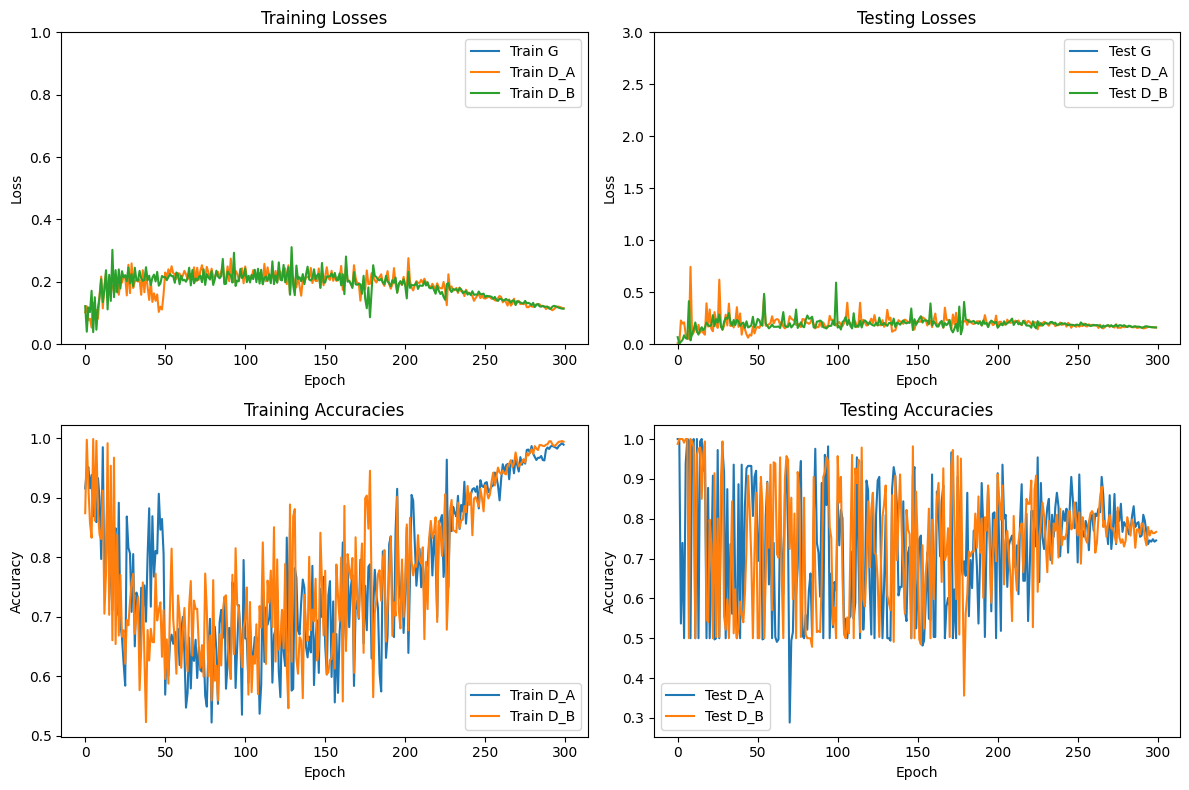

In [11]:
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(range(nepoch), train_G_loss, label='Train G')
plt.plot(range(nepoch), train_DA_loss, label='Train D_A')
plt.plot(range(nepoch), train_DB_loss, label='Train D_B')
plt.title('Training Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.ylim(0, 1)

plt.subplot(2, 2, 2)
plt.plot(range(nepoch), test_G_loss, label='Test G')
plt.plot(range(nepoch), test_DA_loss, label='Test D_A')
plt.plot(range(nepoch), test_DB_loss, label='Test D_B')
plt.title('Testing Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.ylim(0, 3)

# Plot accuracy curves
plt.subplot(2, 2, 3)
plt.plot(range(nepoch), train_DA_acc, label='Train D_A')
plt.plot(range(nepoch), train_DB_acc, label='Train D_B')
plt.title('Training Accuracies')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
# plt.ylim(0, 1)

plt.subplot(2, 2, 4)
plt.plot(range(nepoch), test_DA_acc, label='Test D_A')
plt.plot(range(nepoch), test_DB_acc, label='Test D_B')
plt.title('Testing Accuracies')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
# plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [10]:
for epoch in range(300):
    if train_DA_acc[epoch] < 0.6 and train_DB_acc[epoch]< 0.6:
        print(epoch)
        print(train_DA_acc[epoch])
        print(train_DB_acc[epoch])
        

50
0.5690104141831398
0.5953776016831398
79
0.5221294956281781
0.5592447891831398
83
0.553497868279616
0.5593335671971241
102
0.5888967762390772
0.5690104141831398


# Collect outputs

In [32]:
# dataset = utils.TensorDataset(net_all, labels)
# train_dataset = utils.Subset(dataset, train_id)
# test_dataset = utils.Subset(dataset, test_id)

# # Create dataloaders for full dataset, train, and test sets
# # We use a reasonable batch size to avoid memory issues
# batch_size = 128  # Adjust based on your memory constraints
full_loader = utils.DataLoader(dataset, batch_size=128, shuffle=False)
# train_loader = utils.DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
# test_loader = utils.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [107]:
# Load model from specified epoch
epoch = 138
model_path = f'./saved_model/sleep_daf/'

# Get model filenames for specific epoch
model_files = [f for f in os.listdir(model_path) if f.startswith(f'G_A2B_e{epoch}_')]
if not model_files:
    print(f"No model found for epoch {epoch}")

G_A2B_path = os.path.join(model_path, model_files[0])

model_files = [f for f in os.listdir(model_path) if f.startswith(f'G_B2A_e{epoch}_')]
if not model_files:
    print(f"No model found for epoch {epoch}")

G_B2A_path = os.path.join(model_path, model_files[0])

print(f"Loading Generator A2B from: {G_A2B_path}")
print(f"Loading Generator B2A from: {G_B2A_path}")

# Load model weights
netG_A2B.load_state_dict(torch.load(G_A2B_path))
netG_B2A.load_state_dict(torch.load(G_B2A_path))

# Set to evaluation mode
netG_A2B.eval()
netG_B2A.eval()

# Function to evaluate model and extract results
def extract_results(data_loader, set_name, save=False):
    # Initialize lists to store all data
    all_X_orig = []
    all_A_orig = []
    all_R_orig = []
    all_w = []
    all_z = []
    all_labels = []
    print(f"Processing {set_name} dataset...")
    with torch.no_grad():
        for batch_idx, (X, s) in enumerate(data_loader):
            # Print progress
            print(f"Processing batch {batch_idx+1}/{len(data_loader)}")

            # Move data to device
            X = X.to(device)
            s = s.to(device)

            # Forward pass through generators
            A, w = netG_A2B(X, s)  # A is harmonized data, w is embedding of observed data
            R, z = netG_B2A(A, s)  # R is reconstructed data, z is domain invariant embedding

            # Get domain labels
            s_cpu = s.cpu().numpy().flatten()

            # Detach and move to CPU
            X_cpu = X.cpu().numpy()
            A_cpu = A.cpu().numpy()
            w_cpu = w.cpu().numpy()
            R_cpu = R.cpu().numpy()
            z_cpu = z.cpu().numpy()

            # Convert back from log transform if needed
            if log:
                # Get original shape
                X_reshape = X_cpu.reshape(-1, 68, 68)
                A_reshape = A_cpu.reshape(-1, 68, 68)
                R_reshape = R_cpu.reshape(-1, 68, 68)

                # Inverse log transform: exp(x) - 1
                X_orig = np.exp(X_reshape) - 1
                A_orig = np.exp(A_reshape) - 1
                R_orig = np.exp(R_reshape) - 1
            else:
                # Return to original scale if offset was used
                X_reshape = X_cpu.reshape(-1, 68, 68)
                A_reshape = A_cpu.reshape(-1, 68, 68)
                R_reshape = R_cpu.reshape(-1, 68, 68)
                offset = np.max(net_all.numpy())/2
                X_orig = X_reshape * offset + offset
                A_orig = A_reshape * offset + offset
                R_orig = R_reshape * offset + offset

            # Collect data from this batch
            all_X_orig.append(X_orig)
            all_A_orig.append(A_orig)
            all_R_orig.append(R_orig)
            all_w.append(w_cpu)
            all_z.append(z_cpu)
            all_labels.append(s_cpu)

        # Concatenate all batches
        all_X_orig = np.concatenate(all_X_orig, axis=0)
        all_A_orig = np.concatenate(all_A_orig, axis=0)
        all_R_orig = np.concatenate(all_R_orig, axis=0)
        all_w = np.concatenate(all_w, axis=0)
        all_z = np.concatenate(all_z, axis=0)
        all_labels = np.concatenate(all_labels, axis=0)

        # Split by domain
        short_idx = np.where(all_labels == 0)[0]
        long_idx = np.where(all_labels == 1)[0]

        # Create dictionaries for short and long sleep
        short_sleep_data = {
            'X': all_X_orig[short_idx],  # Original data
            'A': all_A_orig[short_idx],  # Harmonized data
            'R': all_R_orig[short_idx],  # Reconstructed data
            'w': all_w[short_idx],       # Embedding of observed data
            'z': all_z[short_idx]        # Domain invariant embedding
        }

        long_sleep_data = {
            'X': all_X_orig[long_idx],   # Original data
            'A': all_A_orig[long_idx],   # Harmonized data
            'R': all_R_orig[long_idx],   # Reconstructed data
            'w': all_w[long_idx],        # Embedding of observed data
            'z': all_z[long_idx]         # Domain invariant embedding
        }

        # Combined data
        all_data = {
            'X': all_X_orig,             # Original data
            'A': all_A_orig,             # Harmonized data
            'R': all_R_orig,             # Reconstructed data
            'w': all_w,                  # Embedding of observed data
            'z': all_z,                  # Domain invariant embedding
            'domain_labels': all_labels  # Domain labels
        }

        # Save results
        if save:
            savemat(os.path.join(args.save_path, f'{set_name}_short_sleep.mat'), short_sleep_data)
            savemat(os.path.join(args.save_path, f'{set_name}_long_sleep.mat'), long_sleep_data)
            savemat(os.path.join(args.save_path, f'{set_name}_all.mat'), all_data)
            print(f"Saved {set_name} results to {args.save_path}")

        # Calculate and print some statistics
        print(f"\n{set_name} Statistics:")
        print(f"Short sleep subjects: {len(short_idx)}")
        print(f"Long sleep subjects: {len(long_idx)}")
        print(f"Total subjects: {len(all_labels)}")

        # Calculate mean values for each domain
        print("\nMean values:")
        print(f"Short sleep original: {np.mean(all_X_orig[short_idx]):.4f}")
        print(f"Long sleep original: {np.mean(all_X_orig[long_idx]):.4f}")
        print(f"Short sleep harmonized: {np.mean(all_A_orig[short_idx]):.4f}")
        print(f"Long sleep harmonized: {np.mean(all_A_orig[long_idx]):.4f}")
        print(f"Short sleep reconstructed: {np.mean(all_R_orig[short_idx]):.4f}")
        print(f"Long sleep reconstructed: {np.mean(all_R_orig[long_idx]):.4f}")

        # Calculate MSE between original and reconstructed
        short_mse = np.mean((all_X_orig[short_idx] - all_R_orig[short_idx])**2)
        long_mse = np.mean((all_X_orig[long_idx] - all_R_orig[long_idx])**2)
        all_mse = np.mean((all_X_orig - all_R_orig)**2)

        print("\nMSE between original and reconstructed:")
        print(f"Short sleep: {short_mse:.4f}")
        print(f"Long sleep: {long_mse:.4f}")
        print(f"All subjects: {all_mse:.4f}")

        # Return data for further analysis if needed
        return all_data, short_sleep_data, long_sleep_data

Loading Generator A2B from: ./saved_model/sleep_daf/G_A2B_e138_G8.415_gan0.539_cyc8.0_dep0.322.pth
Loading Generator B2A from: ./saved_model/sleep_daf/G_B2A_e138_G8.415_gan0.539_cyc8.0_dep0.322.pth


In [200]:
# print("\nEvaluating on full dataset...")
full_all, full_short, full_long = extract_results(full_loader, 'full')
# test_all, test_short, test_long = extract_results(test_loader, 'test')

Processing full dataset...
Processing batch 1/13
Processing batch 2/13
Processing batch 3/13
Processing batch 4/13
Processing batch 5/13
Processing batch 6/13
Processing batch 7/13
Processing batch 8/13
Processing batch 9/13
Processing batch 10/13
Processing batch 11/13
Processing batch 12/13
Processing batch 13/13

full Statistics:
Short sleep subjects: 766
Long sleep subjects: 860
Total subjects: 1626

Mean values:
Short sleep original: 89.2554
Long sleep original: 91.2770
Short sleep harmonized: 93.1164
Long sleep harmonized: 95.9637
Short sleep reconstructed: 83.9896
Long sleep reconstructed: 87.0596

MSE between original and reconstructed:
Short sleep: 19792.2344
Long sleep: 21446.8047
All subjects: 20667.3574


In [109]:
from mne.viz import circular_layout
from mne_connectivity.viz import plot_connectivity_circle

In [110]:
import matplotlib.pyplot as plt
import matplotlib

cmap = plt.cm.tab20c
labels = {
    'bankssts': cmap(0),
    'caudalanteriorcingulate': cmap(1),
    'caudalmiddlefrontal': cmap(1),
    'cuneus': cmap(2),
    'entorhinal': cmap(3),
    'fusiform': cmap(4),
    'inferiorparietal': cmap(5),
    'inferiortemporal': cmap(5),
    'isthmuscingulate': cmap(6),
    'lateraloccipital': cmap(7),
    'lateralorbitofrontal': cmap(7),
    'lingual': cmap(8),
    'medialorbitofrontal': cmap(9),
    'middletemporal': cmap(10),
    'parahippocampal': cmap(11),
    'paracentral': cmap(11),
    'parsopercularis': cmap(11),
    'parsorbitalis': cmap(11),
    'parstriangularis': cmap(11),
    'pericalcarine': cmap(12),
    'postcentral': cmap(13),
    'posteriorcingulate': cmap(13),
    'precentral': cmap(14),
    'precuneus': cmap(14),
    'rostralanteriorcingulate': cmap(15),
    'rostralmiddlefrontal': cmap(15),
    'superiorfrontal': cmap(16),
    'superiorparietal': cmap(16),
    'superiortemporal': cmap(16),
    'supramarginal': cmap(16),
    'frontalpole': cmap(16),
    'temporalpole': cmap(17),
    'transversetemporal': cmap(18),
    'insula': cmap(19)
}

label_colors = list()
label_colors.extend(list(labels.values())[::-1])  
label_colors.extend(list(labels.values()))

lh_labels = ['lh-' + label for label in labels.keys()]
rh_labels = ['rh-' + label for label in labels.keys()]

node_order = list()
node_order.extend(lh_labels[::-1])  
node_order.extend(rh_labels)

node_angles = circular_layout(node_order, node_order, start_pos=90,
                              group_boundaries=[0, len(node_order) / 2])

n=39
x = 0.32 # 0.32
cmap = plt.cm.jet
lower = cmap(np.linspace(0, x, n))
white = np.ones((80-2*n,4))
upper = cmap(np.linspace(1-x, 1, n))
colors = np.vstack((lower, white, upper))
mycmap = matplotlib.colors.LinearSegmentedColormap.from_list('map_white', colors)

In [111]:
node_codes_l = ['l-FL-3','11','13','16','17','18','19','23','26','27','31','l-SU-34','l-LC-2','9','15','22','25','l-PL-7','21','24','28','30','l-TL-1','5','6','8','14','29','32','33','l-OL-4','10','12','20']
nodes_codes_r = ['20','12','10','4-OL-r','33','32','29','14','8','6','5','1-TL-r','30','28','24','21','7-PL-r','25','22','15','9','l_LC-2','34-SU-r','31','27','26','23','19','18','17','16','13','11','3-FL-l']
nodes_codes = node_codes_l+nodes_codes_r

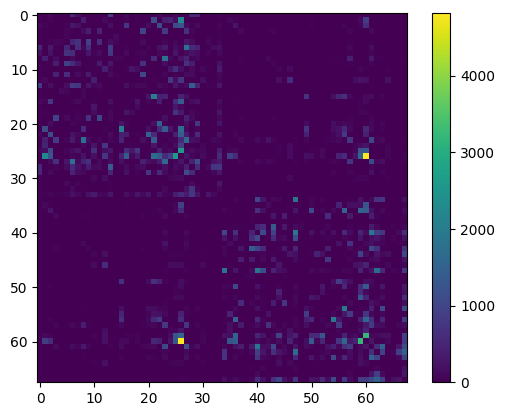

In [201]:
plt.imshow(full_long['X'].mean(0))
plt.colorbar()

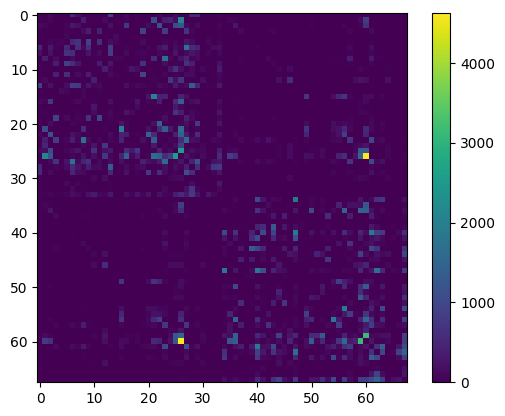

In [202]:
plt.imshow(full_short['X'].mean(0))
plt.colorbar()

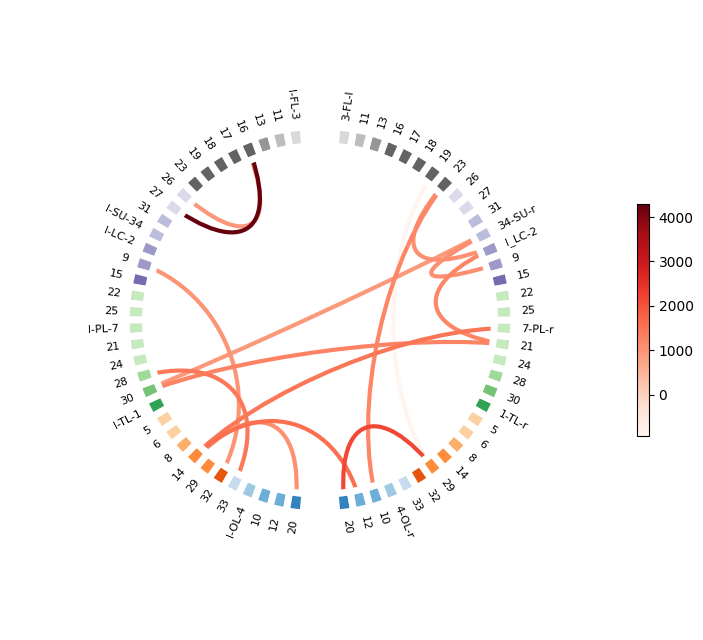

In [113]:
fig, ax = plt.subplots(figsize=(10, 10), 
                       subplot_kw=dict(polar=True))
net=full_long['A'].mean(0)-full_long['X'].mean(0)
# net=hcp_di_197-hcp_197

fig, ax = plot_connectivity_circle(net.reshape(68,68),
                         node_angles=node_angles,
                         node_colors=label_colors,
                         facecolor='white',
                         textcolor='black',
                         node_edgecolor='white',
                         colormap="Reds",
                         node_height=1,
                         node_linewidth=5,
#                          vmin=-500,
#                          vmax=500,
                         node_names=nodes_codes,
                         colorbar=True, colorbar_pos=(-0.3, 0.5), colorbar_size=.3,
                         fontsize_colorbar=10,# padding=1,
                         linewidth=3,
#                          title=titles[i],
                         n_lines=15,ax=ax)

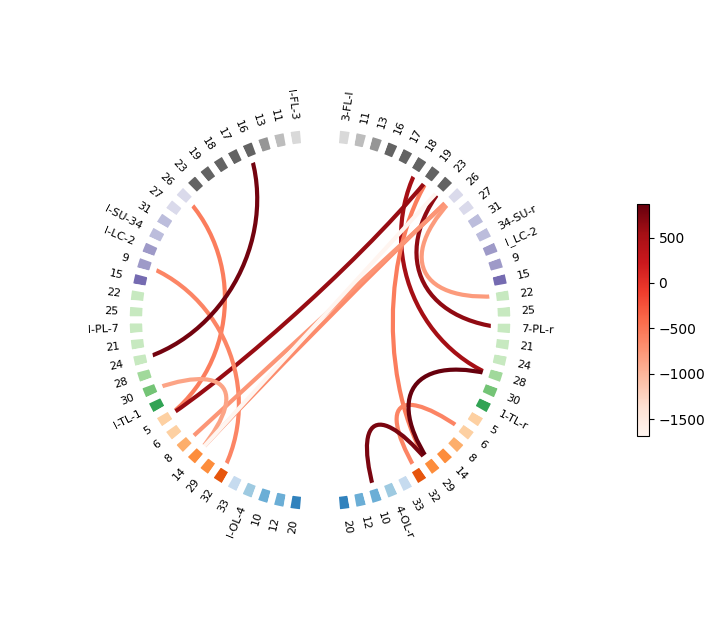

In [98]:
fig, ax = plt.subplots(figsize=(10, 10), 
                       subplot_kw=dict(polar=True))
net=full_short['A'].mean(0)-full_short['X'].mean(0)
# net=hcp_di_197-hcp_197

fig, ax = plot_connectivity_circle(net.reshape(68,68),
                         node_angles=node_angles,
                         node_colors=label_colors,
                         facecolor='white',
                         textcolor='black',
                         node_edgecolor='white',
                         colormap="Reds",
                         node_height=1,
                         node_linewidth=5,
#                          vmin=-500,
#                          vmax=500,
                         node_names=nodes_codes,
                         colorbar=True, colorbar_pos=(-0.3, 0.5), colorbar_size=.3,
                         fontsize_colorbar=10,# padding=1,
                         linewidth=3,
#                          title=titles[i],
                         n_lines=15,ax=ax)

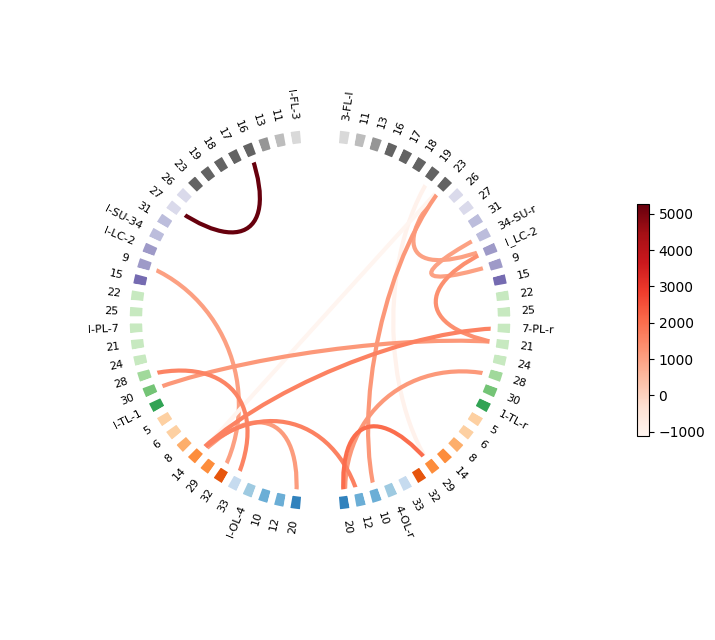

In [114]:
fig, ax = plt.subplots(figsize=(10, 10), 
                       subplot_kw=dict(polar=True))
net=test_long['A'].mean(0)-test_long['X'].mean(0)
# net=hcp_di_197-hcp_197

fig, ax = plot_connectivity_circle(net.reshape(68,68),
                         node_angles=node_angles,
                         node_colors=label_colors,
                         facecolor='white',
                         textcolor='black',
                         node_edgecolor='white',
                         colormap="Reds",
                         node_height=1,
                         node_linewidth=5,
#                          vmin=-500,
#                          vmax=500,
                         node_names=nodes_codes,
                         colorbar=True, colorbar_pos=(-0.3, 0.5), colorbar_size=.3,
                         fontsize_colorbar=10,# padding=1,
                         linewidth=3,
#                          title=titles[i],
                         n_lines=15,ax=ax)

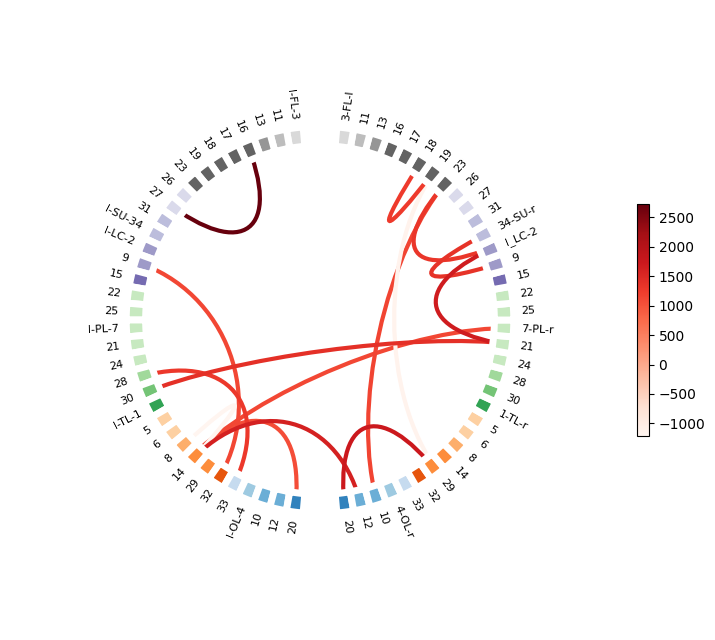

In [115]:
fig, ax = plt.subplots(figsize=(10, 10), 
                       subplot_kw=dict(polar=True))
net=test_short['A'].mean(0)-test_short['X'].mean(0)
# net=hcp_di_197-hcp_197

fig, ax = plot_connectivity_circle(net.reshape(68,68),
                         node_angles=node_angles,
                         node_colors=label_colors,
                         facecolor='white',
                         textcolor='black',
                         node_edgecolor='white',
                         colormap="Reds",
                         node_height=1,
                         node_linewidth=5,
#                          vmin=-500,
#                          vmax=500,
                         node_names=nodes_codes,
                         colorbar=True, colorbar_pos=(-0.3, 0.5), colorbar_size=.3,
                         fontsize_colorbar=10,# padding=1,
                         linewidth=3,
#                          title=titles[i],
                         n_lines=15,ax=ax)

In [175]:
sample_short = torch.tensor(full_short['X'][34:34+128].reshape(-1, 68*68))
sample_long = torch.tensor(full_long['X'][34:34+128].reshape(-1, 68*68))
sample_mix = torch.tensor(np.concatenate((full_short['X'][34:34+64].reshape(-1, 68*68),full_long['X'][34:34+64].reshape(-1, 68*68))))

In [176]:
sample_s = torch.cat((torch.zeros(64),torch.ones(64))).view(-1,1)

In [177]:
sample_s.shape

torch.Size([128, 1])

In [196]:
sig=15000
print(dependence(sample_mix, sample_s, sig=sig))
print(dependence(sample_long, sample_s, sig=sig))
print(dependence(sample_short, sample_s, sig=sig))

tensor(0.0020)
tensor(0.0016)
tensor(0.0018)


In [ ]:
import sys
import torch
import random
import time
from models import *
from utils import *
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from torch.utils.data.sampler import SubsetRandomSampler
import os
import logging
logging.basicConfig(filename='./logs/daf-sleep.log', level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [ ]:
def set_seed(seed_value=973028):
    """Set seed for reproducibility."""
    random.seed(seed_value)  # Python random module
    np.random.seed(seed_value)  # Numpy module
    torch.manual_seed(seed_value)  # PyTorch
    os.environ['PYTHONHASHSEED'] = str(seed_value)  # Python hash seed
    
    # CUDA reproducibility
    torch.cuda.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)  # if use multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

# Unsupervised DAF

## Load brain connectome data

(adjacency matrices)

In [ ]:
dat_abcd = loadmat('../abcd/new_abcd_cog.mat')
dat_hcp = loadmat('../hcp/HCP_subcortical_CMData_desikan.mat')
tensor_abcd = dat_abcd['count_network']
tensor_hcp = dat_hcp['loaded_tensor_sub']

In [ ]:
# whether to apply log transformation to the adjacency matrices)
log=True

In [ ]:
set_seed(1972014)
# np.random.seed(123456)
# orders = np.random.permutation(np.arange(68))
# offset = 18994
net_abcd = []
for i in range(tensor_abcd.shape[2]):
    ith = np.float32(tensor_abcd[:,:,i])
    if log:
        ith = np.log(ith+1)
    ith = ith.reshape(68*68)
    net_abcd.append(ith)
n_abcd = len(net_abcd)

net_hcp = []
for i in range(tensor_hcp.shape[3]):
    ith = np.float32(tensor_hcp[:,:,0,i] + np.transpose(tensor_hcp[:,:,0,i]))
    ith = ith[18:86, 18:86]
    if log:
        ith = np.log(ith+1)
#     np.fill_diagonal(ith,np.mean(ith, 0))
    ith = ith.reshape(68*68)
    net_hcp.append(ith)
n_hcp = len(net_hcp)

For similicity, sample from ABCD and HCP

In [ ]:
_, id_abcd = train_test_split(range(n_abcd), test_size=892/n_abcd, random_state=42) # big 5079, small 173
_, id_hcp = train_test_split(range(n_hcp), test_size=173/n_hcp, random_state=42) # big 5079, small 173

print('abcd',len(id_abcd))
print('hcp',len(id_hcp))

abcd 892
hcp 173


In [ ]:
net_abcd = [net_abcd[i] for i in id_abcd]
net_hcp = [net_hcp[i] for i in id_hcp]
net_all = net_abcd + net_hcp

## preprocess

In [ ]:
if log:
    net_all = torch.stack([torch.Tensor(i) for i in net_all]).view(-1,1,68,68)
else:
    # If no log transformation, scale data to range [0,1] (default in cycle gan)
    offset = np.max(net_all)/2 # 9497
    net_all = torch.stack([torch.Tensor((i-offset)/offset) for i in net_all]).view(-1,1,68,68)

n_abcd, n_hcp = len(id_abcd), len(id_hcp)
n = n_abcd + n_hcp
# domain label: ABCD(0) HCP(1)
labels = torch.cat((torch.tensor([0]).expand(n_abcd,1), torch.tensor([1]).expand(n_hcp,1)))

## Data loader

In [ ]:
set_seed(1972034)
nepoch = 300
dataset = utils.TensorDataset(net_all, labels)
# split train and validataion 
train_id, test_id = train_test_split(list(range(n)),train_size=0.9, random_state=42)
train_dataset = utils.Subset(dataset, train_id)
test_dataset = utils.Subset(dataset, test_id)
train_loader = utils.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = utils.DataLoader(test_dataset, batch_size=len(test_id), shuffle=False)

## DAF model configuration

In [ ]:
# Networks
set_seed(1972014)
netG_A2B = Generator(input_nc=1, output_nc=1, init_depth=48, s_depth=10, n_residual_blocks=5).to(device)
netG_B2A = Generator(input_nc=1, output_nc=1, init_depth=48, s_depth=10, n_residual_blocks=5).to(device)
netD_A = Discriminator(input_nc=1, init_depth=48).to(device)
netD_B = Discriminator(input_nc=1, init_depth=48).to(device)

# Lossess
criterion_GAN = torch.nn.MSELoss()
criterion_cycle = torch.nn.L1Loss()

# Optimizers & LR schedulers
optimizer_G = torch.optim.Adam(itertools.chain(netG_A2B.parameters(), netG_B2A.parameters()),
                                lr=0.0002, betas=(0.5, 0.999))
optimizer_D_A = torch.optim.Adam(netD_A.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D_B = torch.optim.Adam(netD_B.parameters(), lr=0.0002, betas=(0.5, 0.999))

lr_scheduler_G = torch.optim.lr_scheduler.LambdaLR(optimizer_G, lr_lambda=LambdaLR(nepoch, 0, nepoch/2).step)
lr_scheduler_D_A = torch.optim.lr_scheduler.LambdaLR(optimizer_D_A, lr_lambda=LambdaLR(nepoch, 0, nepoch/2).step)
lr_scheduler_D_B = torch.optim.lr_scheduler.LambdaLR(optimizer_D_B, lr_lambda=LambdaLR(nepoch, 0, nepoch/2).step)



## Train

In [ ]:
train_G_loss=[]
test_G_loss=[]
train_DA_loss=[]
test_DA_loss=[]
train_DB_loss=[]
test_DB_loss=[]
# frequency to monitor test loss
evaluate_every = 1

for epoch in range(0, nepoch):
    
    G_losses=[]
    DA_losses=[]
    DB_losses=[]
    iden=[]
    gan=[]
    cyc=[]
    dep=[]

    tic = time.perf_counter()
    for i, (A, s) in enumerate(train_loader):
        
        # Set model input
        real_A = A.to(device)
        real_B = A.to(device)
        s = s.to(device)
        bs = real_A.shape[0]
        
        # Inputs & targets memory allocation
        Tensor = torch.FloatTensor
        target_real = Variable(Tensor(bs,1).fill_(1.0), requires_grad=False).to(device)
        target_fake = Variable(Tensor(bs,1).fill_(0.0), requires_grad=False).to(device)
        
        ###### Generators A2B and B2A ######
        optimizer_G.zero_grad()
        
        # GAN loss 
        fake_B, _ = netG_A2B(real_A, s)
        pred_fake = netD_B(fake_B)
        loss_GAN_A2B = criterion_GAN(pred_fake, target_real)
        
        fake_A, _ = netG_B2A(real_B, s)
        pred_fake = netD_A(fake_A)
        loss_GAN_B2A = criterion_GAN(pred_fake, target_real)
        
        # Cycle loss
        recovered_A, _ = netG_B2A(fake_B, s)
        loss_cycle_ABA = criterion_cycle(recovered_A, real_A)*10.0

        recovered_B, _ = netG_A2B(fake_A, s)
        loss_cycle_BAB = criterion_cycle(recovered_B, real_B)*10.0
        
        # Dependence loss
        xt = fake_B.view(bs, -1)
        s = s.view(bs, 1)
        DLR = dependence(xt, s, sig=20, device=device) 

        loss_G = loss_GAN_A2B + loss_GAN_B2A + loss_cycle_ABA + loss_cycle_BAB + DLR   #+ loss_pred#if feed_iden else loss_GAN_A2B + loss_GAN_B2A + loss_cycle_ABA + loss_cycle_BAB
        loss_G.backward()
        
        optimizer_G.step()
        ###################################

        ###### Discriminator A ######
        optimizer_D_A.zero_grad()

        # Real loss
        pred_real = netD_A(real_A)
        loss_D_real = criterion_GAN(pred_real, target_real)

        # Fake loss
        pred_fake = netD_A(fake_A.detach())
        loss_D_fake = criterion_GAN(pred_fake, target_fake)

        # Total loss
        loss_D_A = (loss_D_real + loss_D_fake)*0.5
        loss_D_A.backward()

        optimizer_D_A.step()
        ###################################

        ###### Discriminator B ######
        optimizer_D_B.zero_grad()

        # Real loss
        pred_real = netD_B(real_B)
        loss_D_real = criterion_GAN(pred_real, target_real)
        
        # Fake loss
        pred_fake = netD_B(fake_B.detach())
        loss_D_fake = criterion_GAN(pred_fake, target_fake)

        # Total loss
        loss_D_B = (loss_D_real + loss_D_fake)*0.5
        loss_D_B.backward()

        optimizer_D_B.step()
        ###################################
        
        # collect loss
        G_losses.append(loss_G.data.item())
        DA_losses.append(loss_D_A.data.item())
        DB_losses.append(loss_D_B.data.item())
        ####
        gan.append(loss_GAN_A2B.data.item() + loss_GAN_B2A.data.item())
        cyc.append(loss_cycle_ABA.data.item() + loss_cycle_BAB.data.item())
        dep.append(DLR.data.item())
        
    # Update learning rates
    lr_scheduler_G.step()
    lr_scheduler_D_A.step()
    lr_scheduler_D_B.step()
    
    G_loss_epoch =  torch.mean(torch.FloatTensor(G_losses))
    DA_loss_epoch =  torch.mean(torch.FloatTensor(DA_losses))
    DB_loss_epoch =  torch.mean(torch.FloatTensor(DB_losses))
    #####
    gan_epoch =  torch.mean(torch.FloatTensor(gan))
    cyc_epoch =  torch.mean(torch.FloatTensor(cyc))
    dep_epoch =  torch.mean(torch.FloatTensor(dep))
    toc = time.perf_counter()
    print(f"trained epoch in {toc - tic:0.4f} seconds") 
    
    if (epoch + 1) % evaluate_every == 0:
        G_loss_test, DA_loss_test, DB_loss_test, gan_test, cyc_test, dep_test = evaluate(netG_A2B, netG_B2A, netD_A, netD_B, 
                                                                                         test_loader, epoch, device, save = True, plot=True,
                                                                                         root='./saved_model/unsup_daf/')
    
    logging.info('-'*15+'train loss'+'-'*15)    
    logging.info(f"Epoch: {epoch + 1}/{nepoch}, loss_D_A: {DA_loss_epoch:.3f}, loss_D_B: {DB_loss_epoch:.3f}, loss_G: {G_loss_epoch:.3f}")
    logging.info(f"Epoch: {epoch + 1}/{nepoch}, loss_gan: {gan_epoch:.3f}, loss_cyc: {cyc_epoch:.3f}, loss_dep: {dep_epoch:.3f}")
    logging.info('-'*15+' test loss'+'-'*15)   
    logging.info(f"Epoch: {epoch + 1}/{nepoch}, loss_D_A: {DA_loss_test:.3f}, loss_D_B: {DB_loss_test:.3f}, loss_G: {G_loss_test:.3f}")
    logging.info(f"Epoch: {epoch + 1}/{nepoch}, loss_gan: {gan_test:.3f}, loss_cyc: {cyc_test:.3f}, loss_dep: {dep_test:.3f}")
    logging.info('*'*40)

    print('-'*15+'train loss'+'-'*15)    
    print(f"Epoch: {epoch + 1}/{nepoch}, loss_D_A: {DA_loss_epoch:.3f}, loss_D_B: {DB_loss_epoch:.3f}, loss_G: {G_loss_epoch:.3f}")
    print(f"Epoch: {epoch + 1}/{nepoch}, loss_gan: {gan_epoch:.3f}, loss_cyc: {cyc_epoch:.3f}, loss_dep: {dep_epoch:.3f}")
    print('-'*15+' test loss'+'-'*15)   
    print(f"Epoch: {epoch + 1}/{nepoch}, loss_D_A: {DA_loss_test:.3f}, loss_D_B: {DB_loss_test:.3f}, loss_G: {G_loss_test:.3f}")
    print(f"Epoch: {epoch + 1}/{nepoch}, loss_gan: {gan_test:.3f}, loss_cyc: {cyc_test:.3f}, loss_dep: {dep_test:.3f}")
    print('*'*40)
    
    train_G_loss.append(G_loss_epoch.item())
    test_G_loss.append(G_loss_test)
    train_DA_loss.append(DA_loss_epoch.item())
    test_DA_loss.append(DA_loss_test)
    train_DB_loss.append(DB_loss_epoch.item())
    test_DB_loss.append(DB_loss_test)

    

trained epoch in 2.3773 seconds
Directory './saved_model/unsup_daf/' was created.
Directory './saved_model/unsup_daf/figs/' was created.
---------------train loss---------------
Epoch: 1/300, loss_D_A: 0.168, loss_D_B: 0.106, loss_G: 36.120
Epoch: 1/300, loss_gan: 1.182, loss_cyc: 34.897, loss_dep: 0.040
--------------- test loss---------------
Epoch: 1/300, loss_D_A: 0.026, loss_D_B: 0.024, loss_G: 34.159
Epoch: 1/300, loss_gan: 1.412, loss_cyc: 32.714, loss_dep: 0.033
****************************************
trained epoch in 1.6452 seconds
---------------train loss---------------
Epoch: 2/300, loss_D_A: 0.105, loss_D_B: 0.188, loss_G: 33.504
Epoch: 2/300, loss_gan: 1.775, loss_cyc: 31.670, loss_dep: 0.059
--------------- test loss---------------
Epoch: 2/300, loss_D_A: 0.087, loss_D_B: 0.100, loss_G: 31.264
Epoch: 2/300, loss_gan: 1.807, loss_cyc: 29.418, loss_dep: 0.039
****************************************
trained epoch in 1.6464 seconds
---------------train loss---------------


Note: specify `plot=True` in `evaluate` to monitor the visualized generated and reconstructed data. Figures are saved in `saved_model/unsup_daf/figs/`.

Figures are 3x6 grid. 

Row 1: observed, row 2: generated, row 3: reconstructed

Column 1-3: ABCD matrices. Column 4-6: HCP matrices.

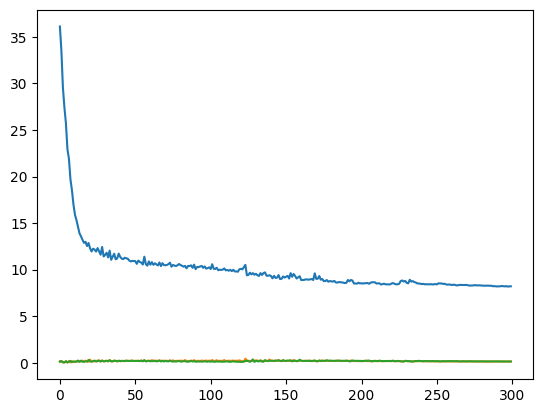

In [ ]:
plt.plot(range(nepoch),train_G_loss)
plt.plot(range(nepoch),train_DA_loss)
plt.plot(range(nepoch),train_DB_loss)
# plt.ylim(0,3)

(0.0, 3.0)

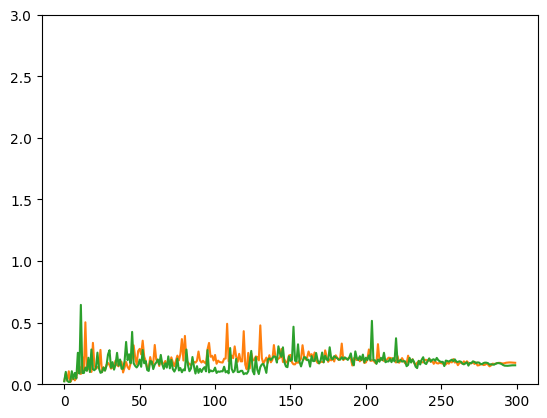

In [ ]:
plt.plot(range(nepoch),test_G_loss)
plt.plot(range(nepoch),test_DA_loss)
plt.plot(range(nepoch),test_DB_loss)
plt.ylim(0,3)

# DAF regression

## Load traits

In [12]:
# Load trait data for ABCD
trait_abcd_all = dat_abcd['nih_cogn']

# Load trait data for HCP
phen_dat = loadmat('../hcp/HCP_Covariates.mat')

# Get subject IDs from both datasets
hcp_all_subject_ids = phen_dat['allsubject_id'].squeeze()  # All subjects in covariates file (1206 subjects)
hcp_connectome_subject_ids = dat_hcp['all_id'].squeeze()   # Subjects with connectome data (1065 subjects)

# Create mapping from HCP connectome subjects to their corresponding indices in the covariates file
# This finds the index in the covariates file for each subject in the connectome data
phen_idx = []
for subject_id in hcp_connectome_subject_ids:
    # Find where this subject appears in the full subject list
    idx = np.where(hcp_all_subject_ids == subject_id)[0]
    if len(idx) > 0:
        phen_idx.append(idx[0])
    else:
        # Handle case where subject not found (shouldn't happen based on our checks)
        print(f"Warning: Subject {subject_id} not found in covariates file")
        phen_idx.append(None)

# Extract only the traits for subjects that have connectome data
# This uses the mapping we created to get the right indices
trait_hcp_all = phen_dat['cog_measure'][:, phen_idx]  # shape: (num_traits, num_connectome_subjects)

# Then use the id_hcp indices which select which of the connectome subjects to use
# Note: If sample=False, id_hcp is all subjects, so this doesn't change anything
trait_hcp_all = trait_hcp_all[:, id_hcp]  # shape: (num_traits, num_selected_subjects)
trait_abcd_all = trait_abcd_all[id_abcd]  # shape: (num_selected_subjects, num_traits)

# Transpose the HCP traits to match the shape of ABCD traits (subjects x traits)
trait_hcp_all = trait_hcp_all.reshape(-1, n_hcp).transpose(1, 0)

# Handle missing values and normalize traits
col_means = np.nanmean(trait_abcd_all, axis=0)
inds = np.where(np.isnan(trait_abcd_all))
trait_abcd_all[inds] = np.take(col_means, inds[1])
means_abcd, stds_abcd = np.mean(trait_abcd_all, axis=0), np.std(trait_abcd_all, axis=0)
trait_abcd_all = (trait_abcd_all - means_abcd) / stds_abcd

col_means = np.nanmean(trait_hcp_all, axis=0)
inds = np.where(np.isnan(trait_hcp_all))
trait_hcp_all[inds] = np.take(col_means, inds[1])
means_hcp, stds_hcp = np.mean(trait_hcp_all, axis=0), np.std(trait_hcp_all, axis=0)
trait_hcp_all = (trait_hcp_all - means_hcp) / stds_hcp

# Handle specific trait if needed
trait_hcp_all[:, 137] = 0

trait_abcd_all = torch.from_numpy(trait_abcd_all)
trait_hcp_all = torch.from_numpy(trait_hcp_all)

print("HCP traits shape:", trait_hcp_all.shape)
print("ABCD traits shape:", trait_abcd_all.shape)

HCP traits shape: torch.Size([173, 175])
ABCD traits shape: torch.Size([892, 30])


/tmp/ipykernel_1726601/303806022.py:47: RuntimeWarning: invalid value encountered in divide
  trait_hcp_all = (trait_hcp_all - means_hcp) / stds_hcp


## Load trained DAF model and transform data

In [13]:
if log:
    net_abcd = torch.stack([torch.Tensor(i) for i in net_abcd]).view(-1,1,68,68)
    net_hcp = torch.stack([torch.Tensor(i) for i in net_hcp]).view(-1,1,68,68)
else:
    offset = np.max(net_s)/2 
    net_abcd = torch.stack([torch.Tensor((i-offset)/offset) for i in net_abcd]).view(-1,1,68,68)
    net_hcp = torch.stack([torch.Tensor((i-offset)/offset) for i in net_hcp]).view(-1,1,68,68)

d=48
netG_A2B = Generator(input_nc=1,output_nc=1,
                     init_depth=d,s_depth=10,
                     bc=True,
                     n_residual_blocks=5,domains=2).to(device)
netG_B2A = Generator(input_nc=1,output_nc=1,init_depth=d,s_depth=10,bc=True,n_residual_blocks=5,domains=2).to(device)
netG_A2B.load_state_dict(torch.load("saved_model/unsup_daf/G_A2B.pth"))
netG_B2A.load_state_dict(torch.load("saved_model/unsup_daf/G_B2A.pth"))


<All keys matched successfully>

In [14]:
with torch.no_grad():
    net1_abcd, z_abcd = netG_A2B(net_abcd.to(device), torch.tensor([0]).expand(n_abcd, 1).to(device))
    netr_abcd, z1_abcd = netG_B2A(net1_abcd.to(device), torch.tensor([0]).expand(n_abcd, 1).to(device))

    net1_hcp, z_hcp = netG_A2B(net_hcp.to(device), torch.tensor([1]).expand(n_hcp, 1).to(device))
    netr_hcp, z1_hcp = netG_B2A(net1_hcp.to(device), torch.tensor([1]).expand(n_hcp, 1).to(device))

    net1_abcd, z_abcd, z1_abcd = net1_abcd.cpu().view(-1, 68*68), z_abcd.cpu(), z1_abcd.cpu()
    net1_hcp, z_hcp, z1_hcp = net1_hcp.cpu().view(-1, 68*68), z_hcp.cpu(), z1_hcp.cpu()

torch.cuda.empty_cache()

In [15]:
# z1_hcp = torch.cat((z_hcp,z1_hcp),1)

## MLP

In [16]:
# metric: coefficient of determination (R^2)
def coefod(yhat,y):
    return 1-(((y-yhat)**2).sum()/((y-y.mean())**2).sum())

In [17]:
def evaluate_MLP(model, x, y, epoch, save=False, root=None):
    model.eval()
    with torch.no_grad():
        x = x.to(device)
        yhat = model(x)
        yhat = yhat.detach().cpu().view(-1)

        loss = F.mse_loss(yhat, y, reduction="mean").item()
        corr = np.corrcoef(yhat,y)[0,1].item()
        cod = coefod(yhat, y).item()
    if save:
        if not os.path.exists(root):
            # Create the directory
            os.makedirs(root)
            print(f"Directory '{root}' was created.")
        torch.save(model.state_dict(), root+'e'+str(epoch)+'.pth')
    return loss, corr, cod

In [18]:
traits = [24] # trait index

In [19]:
# repetitions: in each repetition, randomly divide HCP dataset into K-shot (training) set and remaining (testing) set
rep = 30
num_traits = len(traits)
cor_reps = torch.zeros([rep, num_traits])
mse_reps = torch.zeros([rep, num_traits])
cod_reps = torch.zeros([rep, num_traits])
set_seed()
for t in range(len(traits)):
    
    trait_id = traits[t]
    trait_hcp = trait_hcp_all[:,trait_id].float()
    trait_abcd = trait_abcd_all.float()
    loss_test_list = torch.zeros(rep)
    corr_test_list = torch.zeros(rep)
    cod_test_list = torch.zeros(rep)
    random.seed(1972014)
    r = 0
    count = 0
    redo = False
    # while r < rep: #and count <= 100:
    for r in range(rep):
        id_kshot = random.sample(range(n_hcp), 50)
        id_remain = [ele for ele in list(range(n_hcp)) if ele not in id_kshot]

        trait_remain = trait_hcp[id_remain]
        n_kshot, n_remain = len(id_kshot), len(id_remain)

        print('%%%%%% Train on K-shot set')

        id_kshot_train, id_kshot_val = train_test_split(id_kshot, test_size=0.1, random_state=42)
        train_dataset = utils.TensorDataset(z1_hcp[id_kshot_train], trait_hcp[id_kshot_train])
        train_loader = utils.DataLoader(train_dataset, batch_size=len(id_kshot_train), shuffle=True)
        # val_dataset = utils.TensorDataset(z1_hcp[id_kshot_val], trait_hcp[id_kshot_val])
        # val_loader = utils.DataLoader(val_dataset, batch_size=len(id_kshot_val), shuffle=False)

        # Networks
        model_hcp = MLP(n_traits=1, input_dim=z1_hcp.shape[1]).to(device)

        # Lossess
        criterion_pred = torch.nn.MSELoss()

        # Optimizers & LR schedulers
        optimizer_C = torch.optim.AdamW(model_hcp.parameters(),lr=0.001, betas=(0.9, 0.999))
        nepoch = 100
        corr_val_list = []
        loss_val_list = []
        cod_val_list = []
        for epoch in range(0, nepoch):

            pred=[]

            for i, (A, y) in enumerate(train_loader):

                A = A.to(device)
                y = y.to(device)
                bs = A.shape[0]

                optimizer_C.zero_grad()
                yhat = model_hcp(A)

                # Prediction loss
                loss_pred = criterion_pred(yhat, y.view(bs,-1))# * alpha[epoch]
                loss_pred.backward()

                optimizer_C.step()

                # collect loss
                pred.append(loss_pred.data.item())
            
            # Update learning rates
            pred_epoch = torch.mean(torch.FloatTensor(pred))
            loss_val, corr_val, cod_val = evaluate_MLP(model_hcp, 
                                                          z1_hcp[id_kshot_val], 
                                                          trait_hcp[id_kshot_val], 
                                                          epoch, 
                                                          save=True, 
                                                          root='saved_model/mlp/')
            corr_val_list.append(corr_val)
            loss_val_list.append(loss_val)
            cod_val_list.append(cod_val)
            if epoch % 20==0:
                print('[%d/%d]: loss_train: %.5f, loss_val: %.5f' % ((epoch), nepoch, pred_epoch, loss_val))


        opt_epoch = np.argmin(loss_val_list)
        model_hcp.load_state_dict(torch.load(f'saved_model/mlp/e{opt_epoch}.pth'))
        print('%%%%%% Evaluate on remaining set')
        loss, corr, cod = evaluate_MLP(model_hcp, 
                                       z1_hcp[id_remain], 
                                       trait_hcp[id_remain], 
                                       0, 
                                       save=False)

        loss_test_list[r] = loss 
        corr_test_list[r] = corr
        cod_test_list[r] = cod
        print('loss: %.4f, corr: %.4f' % (loss_test_list[r], corr_test_list[r]))

    cor_reps[:,t] = corr_test_list
    mse_reps[:,t] = loss_test_list
    cod_reps[:,t] = cod_test_list

%%%%%% Train on K-shot set
[0/100]: loss_train: 1.38540, loss_val: 37.45156
[20/100]: loss_train: 0.97879, loss_val: 2.42242
[40/100]: loss_train: 0.72803, loss_val: 2.17823
[60/100]: loss_train: 0.49663, loss_val: 2.10816
[80/100]: loss_train: 0.17848, loss_val: 1.96626
%%%%%% Evaluate on remaining set
loss: 1.6363, corr: 0.1419
%%%%%% Train on K-shot set
[0/100]: loss_train: 0.98555, loss_val: 46.93375
[20/100]: loss_train: 0.81669, loss_val: 0.94197
[40/100]: loss_train: 0.62389, loss_val: 0.76805
[60/100]: loss_train: 0.54799, loss_val: 0.58004
[80/100]: loss_train: 0.21109, loss_val: 0.50317
%%%%%% Evaluate on remaining set
loss: 1.2934, corr: 0.2346
%%%%%% Train on K-shot set
[0/100]: loss_train: 1.37106, loss_val: 30.50185
[20/100]: loss_train: 1.16005, loss_val: 0.24573
[40/100]: loss_train: 0.78718, loss_val: 0.31741
[60/100]: loss_train: 0.33233, loss_val: 0.36624
[80/100]: loss_train: 0.11866, loss_val: 0.24082
%%%%%% Evaluate on remaining set
loss: 0.9053, corr: 0.3009
%%%%

In [35]:
cor_reps.mean(0)

tensor([0.2154])

In [23]:
cor_reps.mean(0)

tensor([0.2234])

In [20]:
cor_reps.mean(0)

tensor([0.2074])